# Default setting

Import the packages used in this notebook.


In [1]:
import pprint
import numpy as np
import matplotlib.pyplot as plt
from dark_emulator2 import DarkEmulator2 as dq2

Create a default `DarkEmulator2` instance.


In [2]:
emu = dq2()

Print the default emulator settings.


In [3]:
emu.show_mode()

npart(1D) :: 3000
lbox :: 1000 [Mpc/h]
Nyquist frequency is 9.4248 [h/Mpc].
Shotnoise limit is 0.0370  [(Mpc/h)^3].
lin_pk_switch :: True
lin_pk_switch_k :: 0.01 [h/Mpc]
pk-nsmooth :: 20
reduce_shotnoise :: False


Load the fiducial cosmology and the allowed parameter ranges.


In [4]:
p = emu.param.get_fid_param()
p_range = emu.param.get_param_range()

print("fiducial parameters")
pprint.pprint(p)
print("\nparameter range")
pprint.pprint(p_range)

fiducial parameters
{'As': 2.206516233894705e-09,
 'Mnu': 0.06,
 'Omega_de': 0.68434,
 'Omega_k': 0.0,
 'Omega_m': 0.3156,
 'h0': 0.6723473803969963,
 'ln(10^10As)': 3.094,
 'ns': 0.9645,
 'omega_b': 0.02225,
 'omega_cdm': 0.1198,
 'sigma8': 0.831,
 'w0': -1,
 'wa': 0}

parameter range
{'As': [2.832614112620091e-10, 3.1570240072959045e-08],
 'Mnu': [0.0, 0.5],
 'Omega_de': [0.4125, 0.938542],
 'Omega_k': [-0.1, 0.1],
 'Omega_m': [0.05, 0.62],
 'S8': [0.6, 0.95],
 'dist': [0.0, 5.0],
 'h0': [0.5, 0.9],
 'ln(10^10As)': [1.0412, 5.7548],
 'ns': [0.916275, 1.012725],
 'omega_b': [0.015, 0.03],
 'omega_cdm': [0.01, 0.3],
 'sigma8': [0.42, 1.3],
 'w': [-1.5, -0.5],
 'w0': [-1.5, -0.5],
 'wa': [-0.5, 0.5]}


# Quick emulation linear and non-linear matter power spectrum

Compute CDM+baryon linear and non-linear matter power spectra at `z=0` using the default `k` grid.


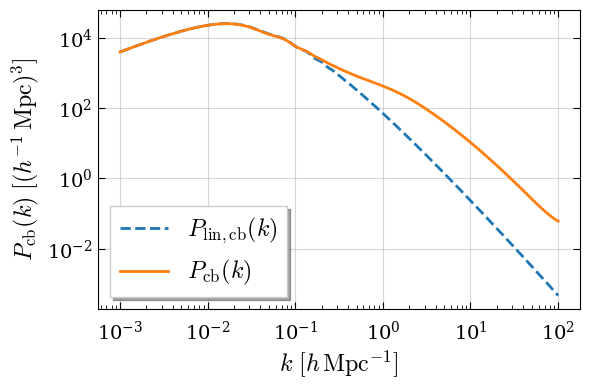

In [5]:
k, pk = emu.get_pk(p)
lin_k, lin_pk = emu.get_lin_pk(p)

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k, lin_pk, "--", lw=2, label=r"$P_\mathrm{lin,cb}(k)$")
plt.plot(k, pk, "-", lw=2, label=r"$P_\mathrm{cb}(k)$")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P_\mathrm{cb}(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

Compute total matter linear and non-linear matter power spectra at `z=0` using the default `k` grid.


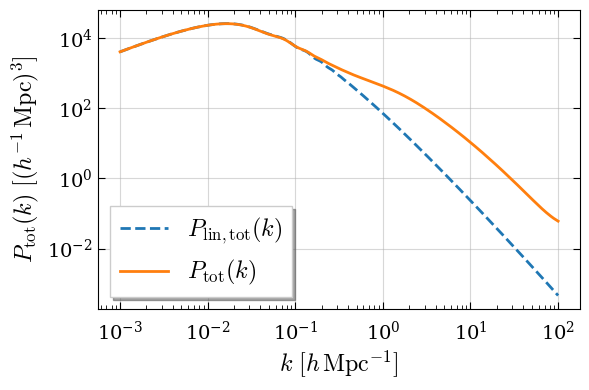

In [6]:
k, pk = emu.get_pk_total(p)
lin_k, lin_pk = emu.get_lin_pk_total(p)

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k, lin_pk, "--", lw=2, label=r"$P_\mathrm{lin,tot}(k)$")
plt.plot(k, pk, "-", lw=2, label=r"$P_\mathrm{tot}(k)$")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P_\mathrm{tot}(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

# Arbitrary klist

When an arbitrary klist is given, it outputs accordingly.

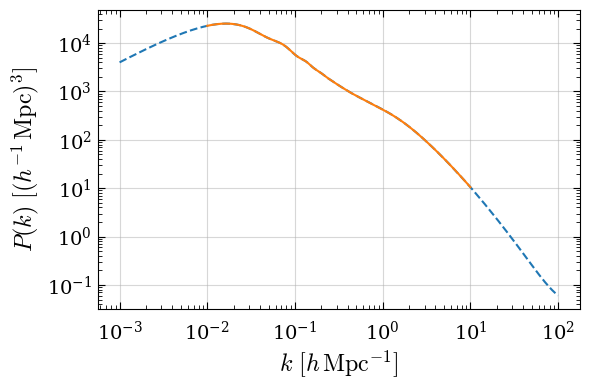

In [7]:
def_k, def_pk = emu.get_pk_total(p)

new_klist = np.logspace(-2,1,1000)
k, pk = emu.get_pk_total(p, klist=new_klist)

fig = plt.figure(figsize=(6, 4))
plt.plot(def_k, def_pk, "--")
plt.plot(k, pk, "-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

# Arbitrary redshift



You can evaluate one redshift at a time by looping over `zred`.


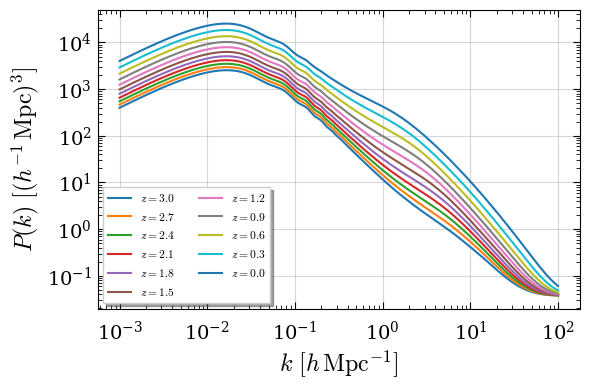

In [8]:
zlist = np.linspace(3,0,11)
fig = plt.figure(figsize=(6, 4))
for z in zlist :
  k, pk = emu.get_pk_total(p, zred=z)
  plt.plot(k, pk, "-", label=rf"$z={z:.1f}$")
plt.legend(ncol=2,fontsize="small")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

# Method of the linear P(k) calculation


The default setting is to use the linear power spectrum emulator because running the Boltzmann code CLASS is time consuming when calculating the linear power spectrum. Optionally, the linear power spectrum emulator can be omitted and the CLASS results used. While the accuracy of the linear power spectrum is guaranteed, it is slower than linear $P(k)$ emulator by several order of magnitude.

CPU times: user 70.7 ms, sys: 0 ns, total: 70.7 ms
Wall time: 14.7 ms
CPU times: user 1min 4s, sys: 4.44 s, total: 1min 9s
Wall time: 9.24 s


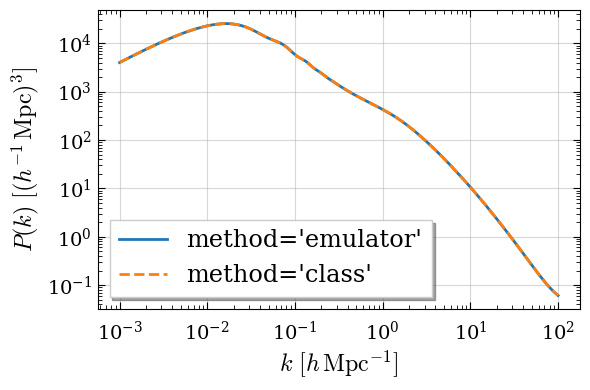

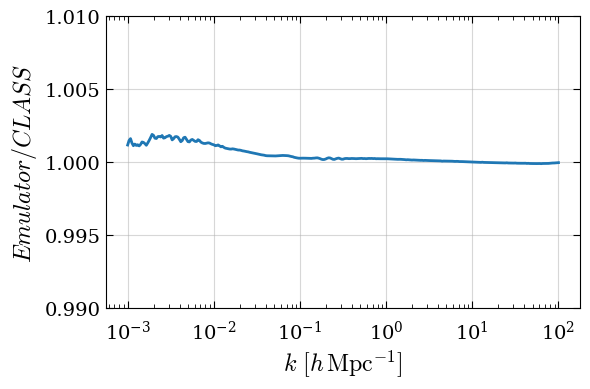

In [9]:
p = emu.param.get_fid_param()

%time k_emu, pk_emu = emu.get_pk(p, method="emulator") # default
%time k_class, pk_class = emu.get_pk(p, method="class") # use linear boltzmann code CLASS

fig = plt.figure(figsize=(6, 4))
plt.plot(k_emu, pk_emu, "-", lw=2, label="method='emulator'")
plt.plot(k_class, pk_class, "--", lw=2, label="method='class'")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(k_emu, pk_emu/pk_class, "-", lw=2)
plt.xscale("log")
plt.yscale("linear")
plt.ylim(0.99,1.01)
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$Emulator/CLASS$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

The same `method` option is available for the linear power spectrum.


CPU times: user 63.6 ms, sys: 0 ns, total: 63.6 ms
Wall time: 18.2 ms
CPU times: user 24.3 ms, sys: 1.4 ms, total: 25.7 ms
Wall time: 2.22 ms


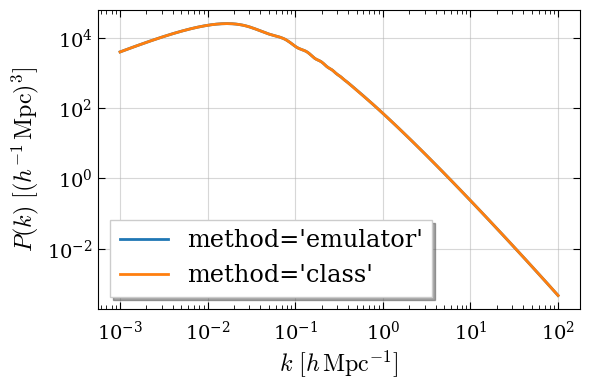

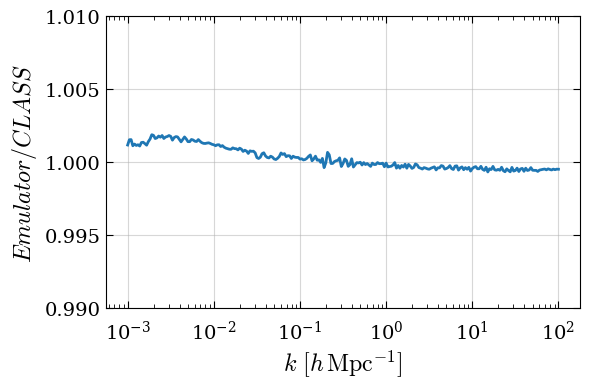

In [10]:
p = emu.param.get_fid_param()

%time lin_k_emu, lin_pk_emu = emu.get_lin_pk(p, method="emulator") # default
%time lin_k_class, lin_pk_class = emu.get_lin_pk(p, klist=lin_k_emu, method="class") # use linear boltzmann code CLASS

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k_emu, lin_pk_emu, "-", lw=2, label="method='emulator'")
plt.plot(lin_k_class, lin_pk_class, "-", lw=2, label="method='class'")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k_emu, lin_pk_emu/lin_pk_class, "-", lw=2)
plt.xscale("log")
plt.yscale("linear")
plt.ylim(0.99,1.01)
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$Emulator/CLASS$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

# Some alias


```python
def get_lin_pk_cb(param, zred, klist=None, method)
def get_lin_pk(param, zred, klist=None, method, pk_type="cb")
```

```python
def get_lin_pk_total(param, zred, klist=None, method)
def get_lin_pk(param, zred, klist=None, method, pk_type="total")
```

```python
def get_pk_cb(param, zred, klist=None, method)
def get_pk(param, zred, klist=None, method, pk_type="cb")
```

```python
def get_pk_total(param, zred, klist=None, method)
def get_pk(param, zred, klist=None, method, pk_type="total")
```